In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/edumagalhaes/quality-prediction-in-a-mining-process/MiningProcess_Flotation_Plant_Database.csv


# Problem statement

Mining industries rely on efficient mineral processing to maximize product quality and operational performance. The quality of the final concentrate is influenced by multiple process parameters such as air flow rates, pulp density, reagent levels, and equipment operating conditions. Manually monitoring and optimizing these variables can be difficult and time-consuming.

This project aims to develop a machine learning model capable of predicting the quality of the mining concentrate using process sensor data. By accurately forecasting concentrate quality, mining operations can improve process control, reduce waste, enhance productivity, and support data-driven decision-making.


# Objective

The objective of this project is to build and evaluate machine learning models that can predict concentrate quality in a mining process based on operational and sensor measurements. Multiple regression algorithms will be compared to identify the most effective model for accurate quality prediction.


In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/edumagalhaes/quality-prediction-in-a-mining-process/MiningProcess_Flotation_Plant_Database.csv')
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


# EDA

In [4]:
df.shape

(737453, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

In [6]:
df.describe()


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453,...,737453,737453,737453,737453,737453,737453,737453,737453,737453,737453
unique,4097,278,293,409317,319416,180189,131143,105805,43675,80442,...,86819,299573,331189,322315,309264,276051,301502,295667,38696,55569
top,2017-09-09 23:00:00,"64,03","6,26","2562,5","534,668","402,246","10,0591","1,75","299,927","255,322",...,"299,487","452,441","608,887","601,06","491,406","513,879","474,37","479,478","65,44","2,08"
freq,180,142560,142560,690,959,1735,1509,3214,13683,1487,...,3405,1013,817,989,733,709,746,905,16920,17100


In [7]:
date_col = df["date"]

In [8]:
df = df.drop("date", axis=1)

for col in df.columns:
    df[col] = (
        df[col]
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [9]:
df["date"] = pd.to_datetime(date_col)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   % Iron Feed                   737453 non-null  float64       
 1   % Silica Feed                 737453 non-null  float64       
 2   Starch Flow                   737453 non-null  float64       
 3   Amina Flow                    737453 non-null  float64       
 4   Ore Pulp Flow                 737453 non-null  float64       
 5   Ore Pulp pH                   737453 non-null  float64       
 6   Ore Pulp Density              737453 non-null  float64       
 7   Flotation Column 01 Air Flow  737453 non-null  float64       
 8   Flotation Column 02 Air Flow  737453 non-null  float64       
 9   Flotation Column 03 Air Flow  737453 non-null  float64       
 10  Flotation Column 04 Air Flow  737453 non-null  float64       
 11  Flotation Col

In [11]:
df.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,date
count,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,...,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453
mean,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,281.082397,...,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763,2017-06-16 03:27:22.656549376
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,...,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000,2017-03-10 01:00:00
25%,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,250.855000,...,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000,2017-05-04 23:00:00
50%,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,298.696000,...,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000,2017-06-16 15:00:00
75%,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,...,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000,2017-07-29 07:00:00
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,...,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000,2017-09-09 23:00:00
std,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,28.558268,...,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554,NaN


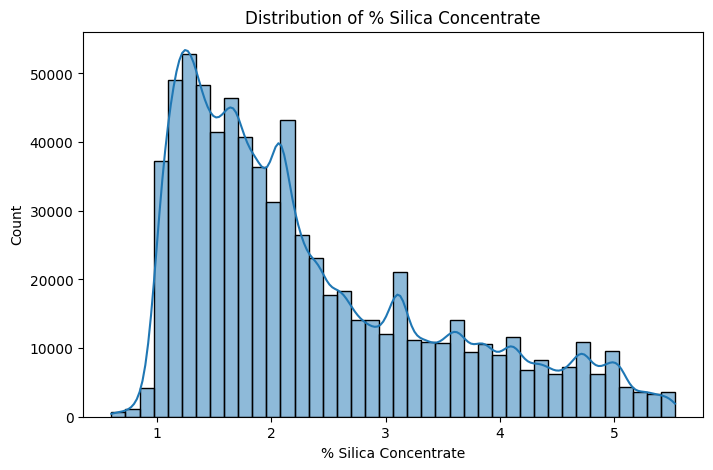

In [12]:
# let's see the distribution of the target variable first

target = "% Silica Concentrate"

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df[target],
    bins=40,
    kde=True
)

plt.title("Distribution of % Silica Concentrate")

plt.show()

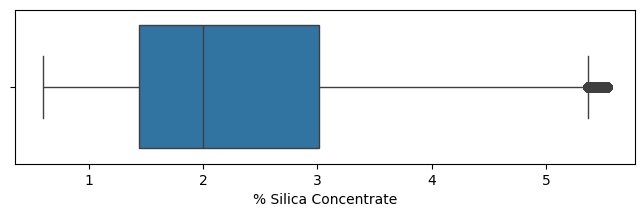

In [13]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df[target]
)

plt.show()

In [14]:
corr = df.corr(numeric_only=True)

corr_target = (
    corr[target]
    .sort_values(ascending=False)
)

print(corr_target)

% Silica Concentrate            1.000000
Amina Flow                      0.156701
% Silica Feed                   0.072724
Ore Pulp Density                0.046984
Flotation Column 02 Level       0.030955
Flotation Column 01 Level       0.017217
Flotation Column 03 Level       0.014246
Ore Pulp Flow                   0.008222
Flotation Column 04 Air Flow   -0.005011
Flotation Column 05 Air Flow   -0.009293
Flotation Column 06 Air Flow   -0.049650
Starch Flow                    -0.066394
Flotation Column 07 Air Flow   -0.071776
% Iron Feed                    -0.077052
Flotation Column 06 Level      -0.102443
Flotation Column 07 Level      -0.141387
Ore Pulp pH                    -0.147739
Flotation Column 04 Level      -0.149456
Flotation Column 02 Air Flow   -0.167398
Flotation Column 05 Level      -0.169170
Flotation Column 03 Air Flow   -0.218891
Flotation Column 01 Air Flow   -0.219158
% Iron Concentrate             -0.800560
Name: % Silica Concentrate, dtype: float64


In [15]:
corr_target_abs = (
    corr["% Silica Concentrate"]
    .drop("% Silica Concentrate")
    .abs()
    .sort_values(ascending=False)
)

print(corr_target_abs.head(10))

% Iron Concentrate              0.800560
Flotation Column 01 Air Flow    0.219158
Flotation Column 03 Air Flow    0.218891
Flotation Column 05 Level       0.169170
Flotation Column 02 Air Flow    0.167398
Amina Flow                      0.156701
Flotation Column 04 Level       0.149456
Ore Pulp pH                     0.147739
Flotation Column 07 Level       0.141387
Flotation Column 06 Level       0.102443
Name: % Silica Concentrate, dtype: float64


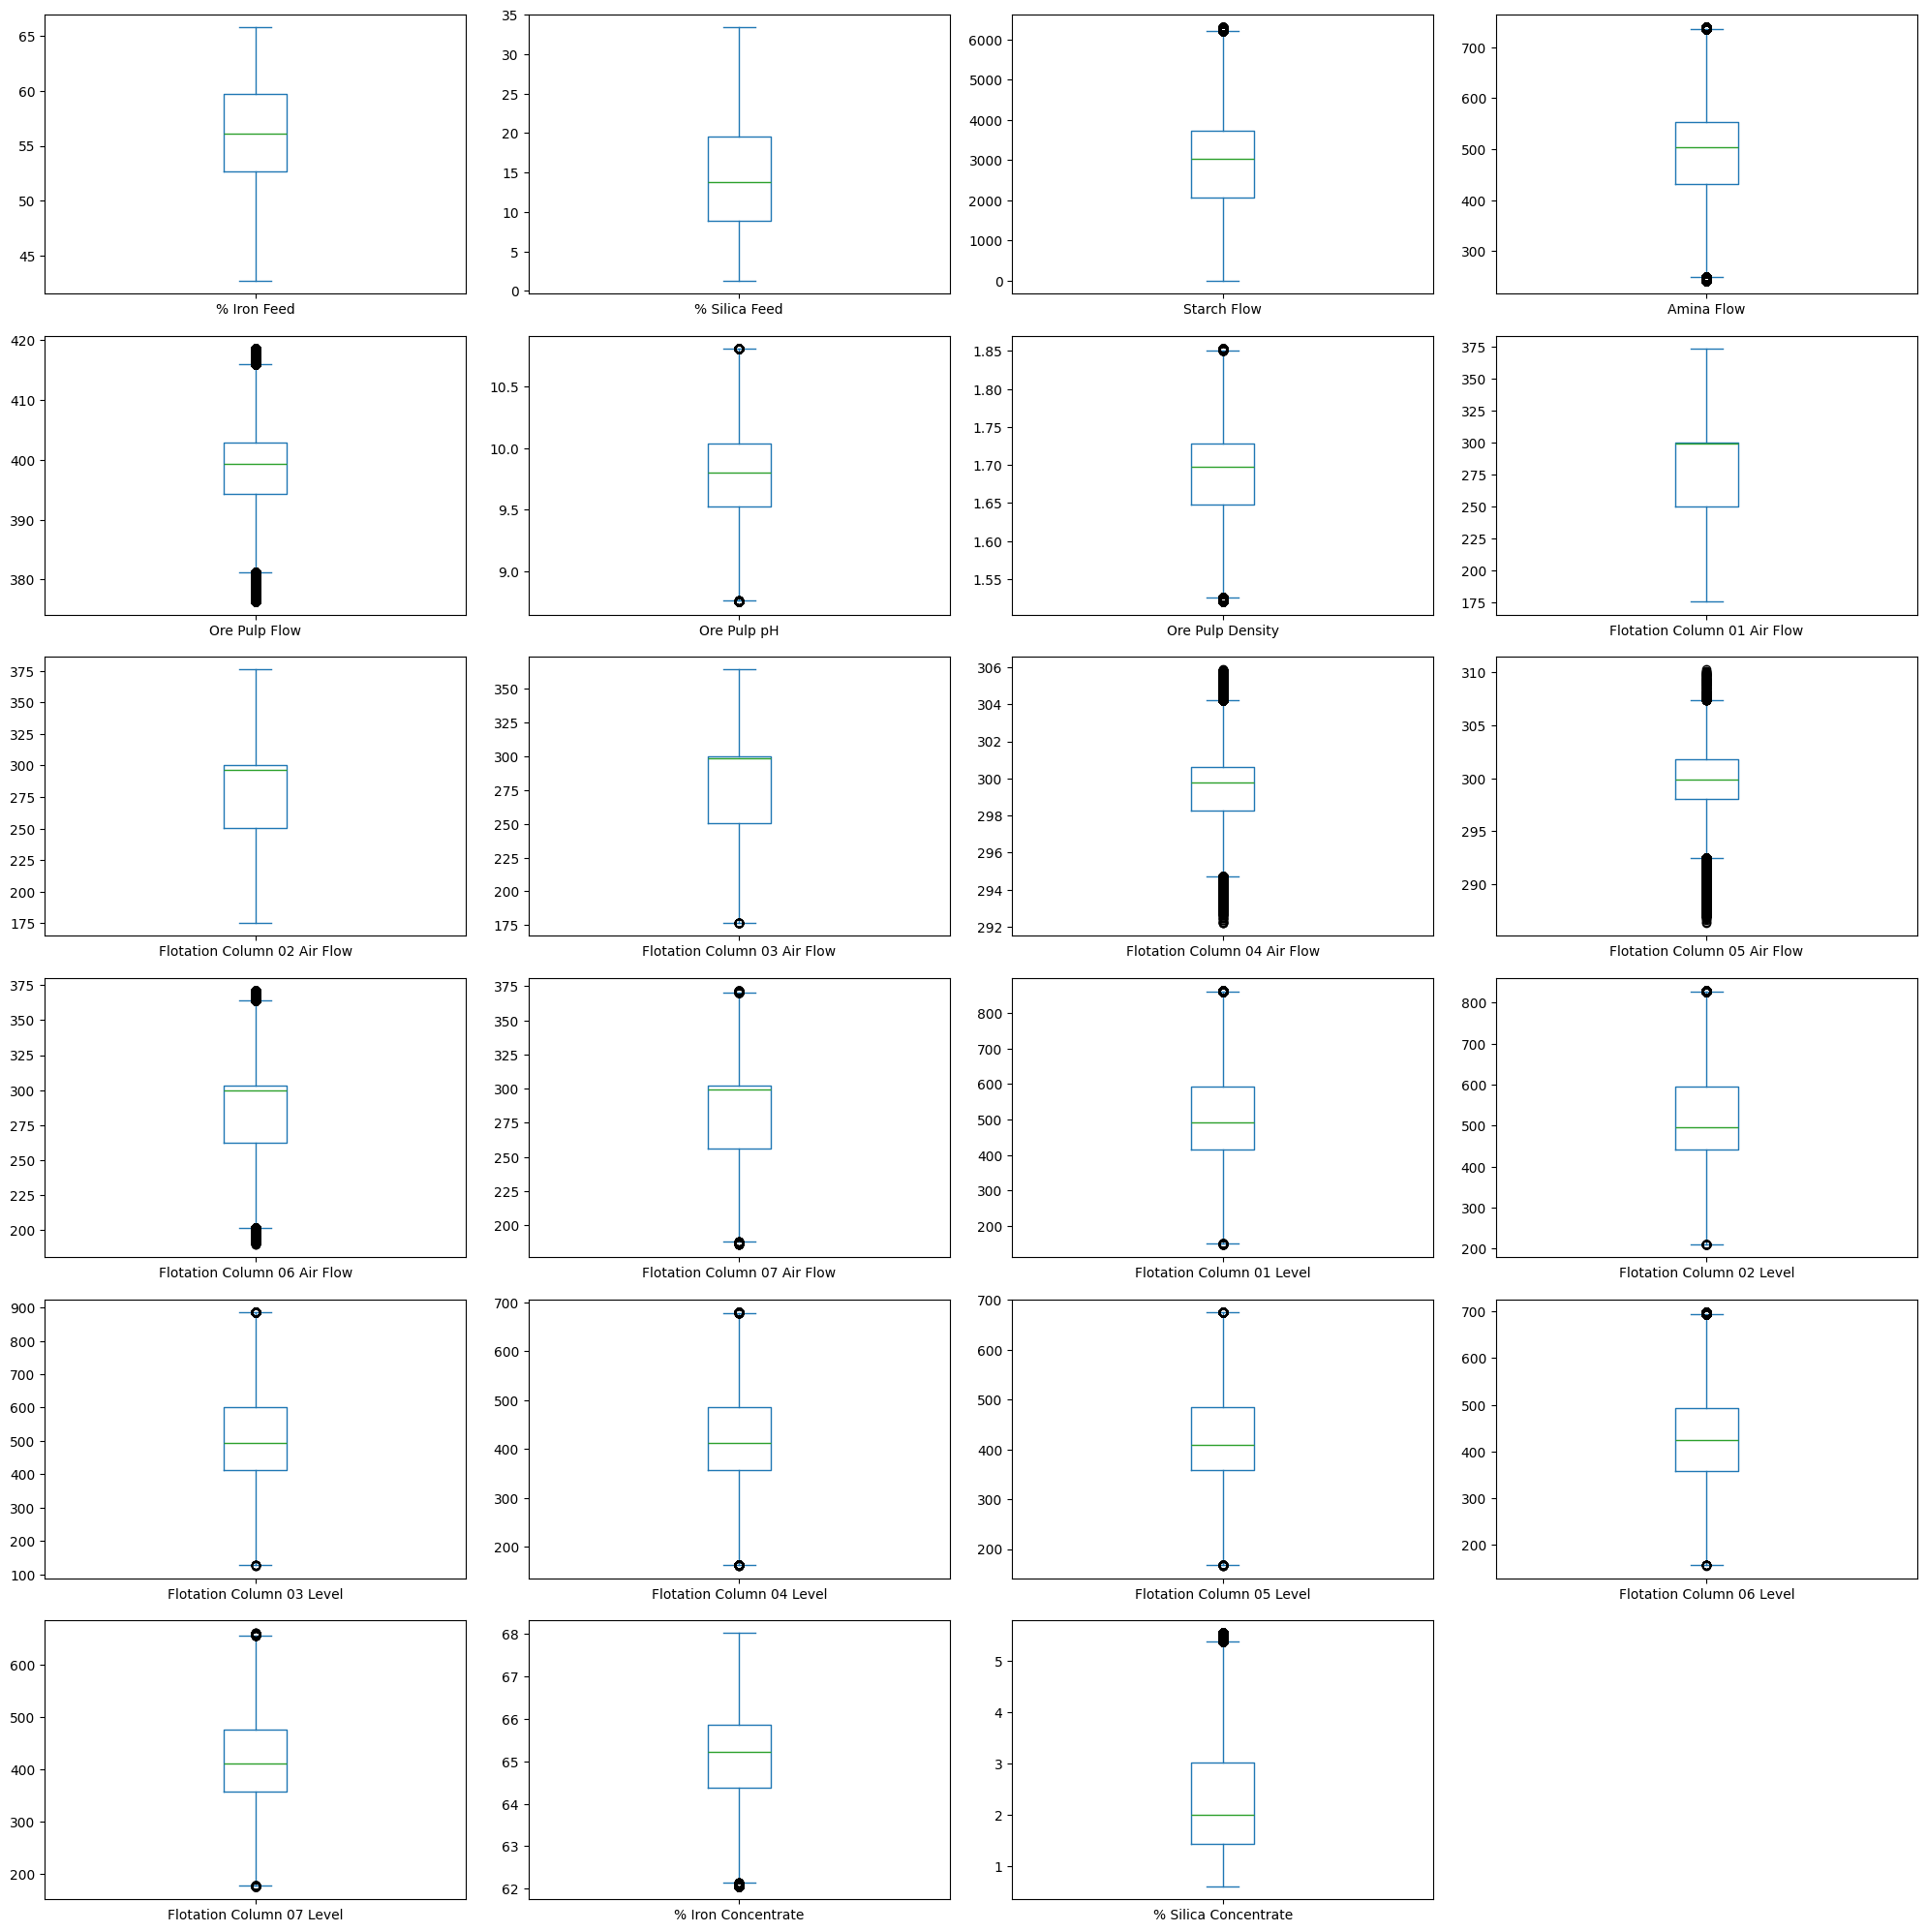

In [16]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(6,4),
    figsize=(20,20),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

**Outlier analysis was conducted using boxplots. A small number of outliers were observed in several process variables. However, the proportion of these observations was relatively low compared to the overall dataset size (737,453 records). Therefore, no immediate outlier removal was performed during the exploratory analysis stage.**

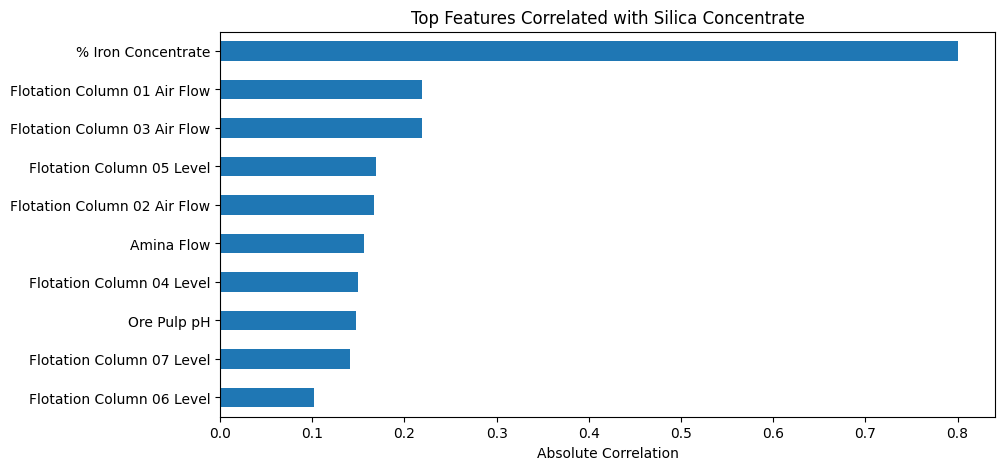

In [17]:
top_features = corr_target_abs.head(10)

plt.figure(figsize=(10,5))

top_features.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Features Correlated with Silica Concentrate"
)

plt.xlabel(
    "Absolute Correlation"
)

plt.show()

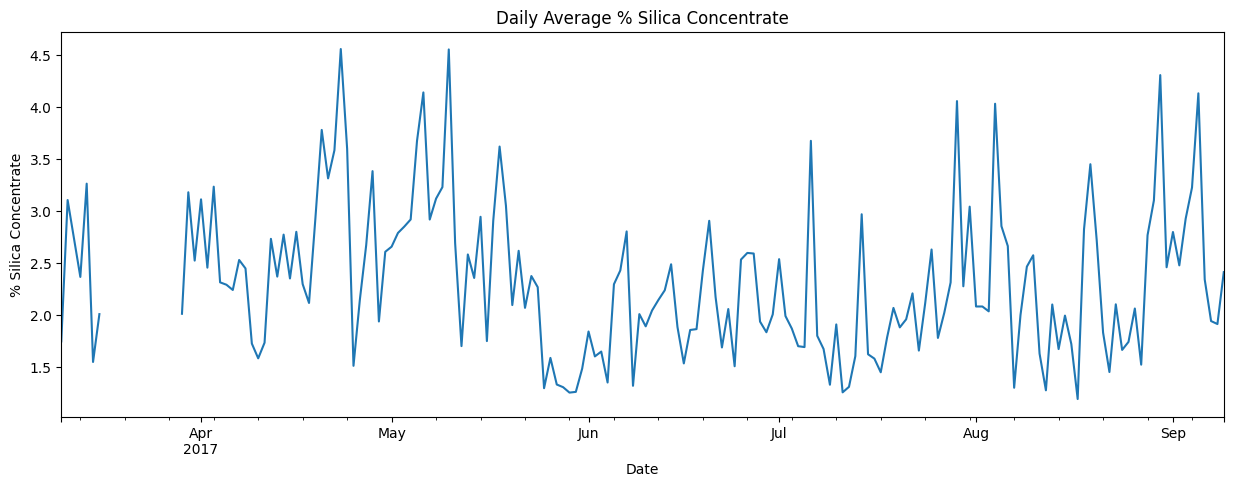

In [18]:
import matplotlib.pyplot as plt

daily_silica = (
    df.set_index("date")
      ["% Silica Concentrate"]
      .resample("D")
      .mean()
)

plt.figure(figsize=(15,5))

daily_silica.plot()

plt.title(
    "Daily Average % Silica Concentrate"
)

plt.xlabel("Date")
plt.ylabel("% Silica Concentrate")

plt.show()

**The daily average silica concentrate exhibited noticeable fluctuations over time rather than following a stable trend. These variations may reflect changes in operating conditions, process parameters, or natural variability within the mining process. No clear long-term upward or downward trend was observed during the analyzed period.**

# Data Cleaning and Feture Extracting

In [19]:
df.isnull().any().sum()

np.int64(0)

In [20]:
df.duplicated().sum()

np.int64(1171)

In [21]:
df = df.drop_duplicates()

In [22]:
df.shape

(736282, 24)

In [23]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour

In [24]:
df.drop("date", axis=1, inplace=True)

In [25]:
df.head(4)

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,year,month,day,hour
0,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,443.558,502.255,446.370,523.344,66.91,1.31,2017,3,10,1
1,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,448.086,496.363,445.922,498.075,66.91,1.31,2017,3,10,1
2,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,449.688,484.411,447.826,458.567,66.91,1.31,2017,3,10,1
3,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,...,446.210,471.411,437.690,427.669,66.91,1.31,2017,3,10,1


# Data Split

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop("% Silica Concentrate", axis=1)
y = df["% Silica Concentrate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("R²:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

R²: 0.6879414607669252
MAE: 0.48262497500766355
RMSE: 0.6276706565915193


In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("R²:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

R²: 0.687941456343296
MAE: 0.4826249820906644
RMSE: 0.6276706610403358


In [30]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

print("R²:", r2_score(y_test, et_pred))
print("MAE:", mean_absolute_error(y_test, et_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, et_pred)))

R²: 0.9999159094488368
MAE: 0.0019369445767394018
RMSE: 0.010303562027776757


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

R²: 0.9995504276568877
MAE: 0.0037526416426854696
RMSE: 0.023823939831228956


In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("R²:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

R²: 0.8831407348306599
MAE: 0.28405267051701344
RMSE: 0.3841009363928624


In [33]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],

    "R² Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, et_pred),
        r2_score(y_test, xgb_pred)
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, et_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, et_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R² Score,MAE,RMSE
0,Extra Trees,0.999916,0.001937,0.010304
1,Random Forest,0.999550,0.003753,0.023824
2,XGBoost,0.883141,0.284053,0.384101
3,Linear Regression,0.687941,0.482625,0.627671
4,Ridge Regression,0.687941,0.482625,0.627671


### Project Summary

This project focuses on predicting the percentage of silica concentrate in an industrial mining flotation process using machine learning techniques. The dataset contained over 737,000 records and multiple process-related variables such as air flow, pulp density, pH, starch flow, and amina flow.

### Challenges Faced

One of the main challenges was the size of the dataset. With more than 737,000 observations, data processing, visualization, and model training required careful handling and computational efficiency. Another challenge was that all features were initially stored as text data due to the use of commas as decimal separators, requiring data type conversion before analysis.

The project also involved extensive exploratory data analysis (EDA) to understand feature distributions, outliers, correlations, and temporal trends. Time-series analysis revealed fluctuations in silica concentration over time, indicating the dynamic nature of the mining process.

### Approach and Solution

The data was cleaned by converting numerical values into proper floating-point format and extracting useful information from the date feature. Exploratory analysis was then performed, including correlation analysis, feature-target relationship analysis, outlier detection, and time-based trend analysis.

Several machine learning models were evaluated, including Linear Regression, Ridge Regression, Random Forest, Extra Trees, and XGBoost. While linear models achieved moderate performance, ensemble tree-based models significantly improved predictive accuracy by capturing complex non-linear relationships within the process variables.

### Key Outcome

The Extra Trees Regressor achieved the best performance with an R² score of approximately 0.9999, followed closely by Random Forest. The results demonstrate that operational process variables can effectively predict silica concentration and support quality monitoring in mining operations.
**